# ADI vs IMD: Rank Correlation Analysis

This notebook compares the Annual Deprivation Index (ADI) with the
Index of Multiple Deprivation (IMD) at the LSOA level. The ADI provides
annual absolute rates across three domains (employment, crime, health);
the IMD provides relative ranks across seven domains, updated sporadically.

We compare across three IMD editions:
- **IMD 2025** (LSOA 2021) vs ADI 2024
- **IMD 2019** (LSOA 2011) vs ADI 2019
- **IMD 2015** (LSOA 2011) vs ADI 2015

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

repo_root = Path.cwd()
if repo_root.name in ("analysis", "nbs", "pts"):
    repo_root = repo_root.parent
while not (repo_root / "config").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent

imd_dir = repo_root / "store" / "inputs" / "imd"
adi_dir = repo_root / "store" / "outputs" / "default" / "lsoa"
crosswalk_path = repo_root / "store" / "inputs" / "crosswalk" / "lsoa11_to_lsoa21.csv"

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 4)})

## Data loading helpers

In [ ]:
def load_adi_for_year(year: int) -> pd.DataFrame:
    """Load and merge all ADI domains for a given calendar year at LSOA level."""
    cc = pd.read_csv(adi_dir / "claimant_counts" / f"claimant_counts_{year}.csv")
    cr = pd.read_csv(adi_dir / "crime" / f"crime_{year}.csv")

    health_files = sorted((adi_dir / "health").glob("health_*.csv"))
    h_file = next((f for f in health_files if f.stem.endswith(f"_{year % 100:02d}")), None)
    if h_file is None:
        h_file = next((f for f in health_files if f"_{year}_" in f.stem), None)

    merged = cc[["LSOA21CD", "LSOA21NM", "claimant_count_rate", "pop"]].copy()
    merged = merged.rename(columns={"claimant_count_rate": "adi_claimant_rate"})

    crime_count_cols = [c for c in cr.columns if c not in ("LSOA21CD", "LSOA21NM", "pop") and "_rate" not in c]
    cr["total_crime"] = cr[crime_count_cols].sum(axis=1)
    cr["adi_crime_rate"] = cr["total_crime"] / cr["pop"].replace(0, np.nan)
    merged = merged.merge(cr[["LSOA21CD", "adi_crime_rate"]], on="LSOA21CD", how="inner")

    if h_file is not None:
        h = pd.read_csv(h_file)
        health_rate_cols = [c for c in h.columns if c.endswith("_afflicted_rate")]
        h_subset = h[["LSOA21CD"] + health_rate_cols].copy()
        h_subset = h_subset.rename(columns={c: f"adi_{c}" for c in health_rate_cols})
        if "adi_DEP_afflicted_rate" in h_subset.columns:
            h_subset["adi_dep_rate"] = h_subset["adi_DEP_afflicted_rate"]
        if "adi_MH_afflicted_rate" in h_subset.columns:
            h_subset["adi_mh_rate"] = h_subset["adi_MH_afflicted_rate"]
        merged = merged.merge(h_subset, on="LSOA21CD", how="inner")

    return merged


def load_imd(edition: str) -> pd.DataFrame:
    df = pd.read_csv(imd_dir / f"imd_{edition}.csv")
    lsoa_col = [c for c in df.columns if c.startswith("LSOA code")][0]
    df = df.rename(columns={
        lsoa_col: "lsoa_code",
        "Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)": "imd_rank",
        "Index of Multiple Deprivation (IMD) Score": "imd_score",
        "Employment Rank (where 1 is most deprived)": "imd_employment_rank",
        "Crime Rank (where 1 is most deprived)": "imd_crime_rank",
        "Health Deprivation and Disability Rank (where 1 is most deprived)": "imd_health_rank",
    })
    return df


def correlate(x, y):
    valid = pd.DataFrame({"x": x, "y": y}).dropna()
    return stats.spearmanr(valid["x"], valid["y"]).statistic


def add_ranks(df):
    df["adi_claimant_rank"] = df["adi_claimant_rate"].rank(ascending=False)
    df["adi_crime_rank"] = df["adi_crime_rate"].rank(ascending=False)
    if "adi_dep_rate" in df.columns:
        df["adi_dep_rank"] = df["adi_dep_rate"].rank(ascending=False)
    return df

## Load and merge datasets

In [ ]:
xwalk = pd.read_csv(crosswalk_path)
xwalk_u = xwalk[xwalk["CHGIND"] == "U"][["LSOA11CD", "LSOA21CD"]]

# IMD 2025 vs ADI 2024 (direct join at LSOA 2021)
imd25 = load_imd("2025")
adi24 = load_adi_for_year(2024)
m25 = add_ranks(adi24.merge(imd25, left_on="LSOA21CD", right_on="lsoa_code", how="inner"))

# IMD 2019 vs ADI 2019 (via crosswalk, unchanged LSOAs only)
imd19 = load_imd("2019")
adi19 = load_adi_for_year(2019)
imd19_x = imd19.merge(xwalk_u, left_on="lsoa_code", right_on="LSOA11CD", how="inner")
m19 = add_ranks(adi19.merge(imd19_x, on="LSOA21CD", how="inner"))

# IMD 2015 vs ADI 2015
imd15 = load_imd("2015")
adi15 = load_adi_for_year(2015)
imd15_x = imd15.merge(xwalk_u, left_on="lsoa_code", right_on="LSOA11CD", how="inner")
m15 = add_ranks(adi15.merge(imd15_x, on="LSOA21CD", how="inner"))

print(f"Matched LSOAs: 2025={len(m25)}, 2019={len(m19)}, 2015={len(m15)}")

Matched LSOAs: 2025=33749, 2019=31801, 2015=31810


## Correlation results

In [ ]:
results = []
for label, m in [("2015", m15), ("2019", m19), ("2025", m25)]:
    row = {"IMD edition": label, "n": len(m)}
    row["Claimant vs IMD overall"] = correlate(m["adi_claimant_rank"], m["imd_rank"])
    row["Crime vs IMD overall"] = correlate(m["adi_crime_rank"], m["imd_rank"])
    row["Claimant vs IMD Employment"] = correlate(m["adi_claimant_rank"], m["imd_employment_rank"])
    row["Crime vs IMD Crime"] = correlate(m["adi_crime_rank"], m["imd_crime_rank"])
    if "adi_dep_rank" in m.columns:
        row["Depression vs IMD Health"] = correlate(m["adi_dep_rank"], m["imd_health_rank"])
    results.append(row)

results_df = pd.DataFrame(results).set_index("IMD edition")
print(results_df.round(3).to_string())

                 n  Claimant vs IMD overall  Crime vs IMD overall  Claimant vs IMD Employment  Crime vs IMD Crime  Depression vs IMD Health
IMD edition                                                                                                                                
2015         31810                    0.859                 0.671                       0.861               0.696                     0.043
2019         31801                    0.882                 0.634                       0.870               0.680                     0.130
2025         33749                    0.848                 0.504                       0.817               0.578                     0.163


## Scatter plots: ADI rank vs IMD rank (2025)

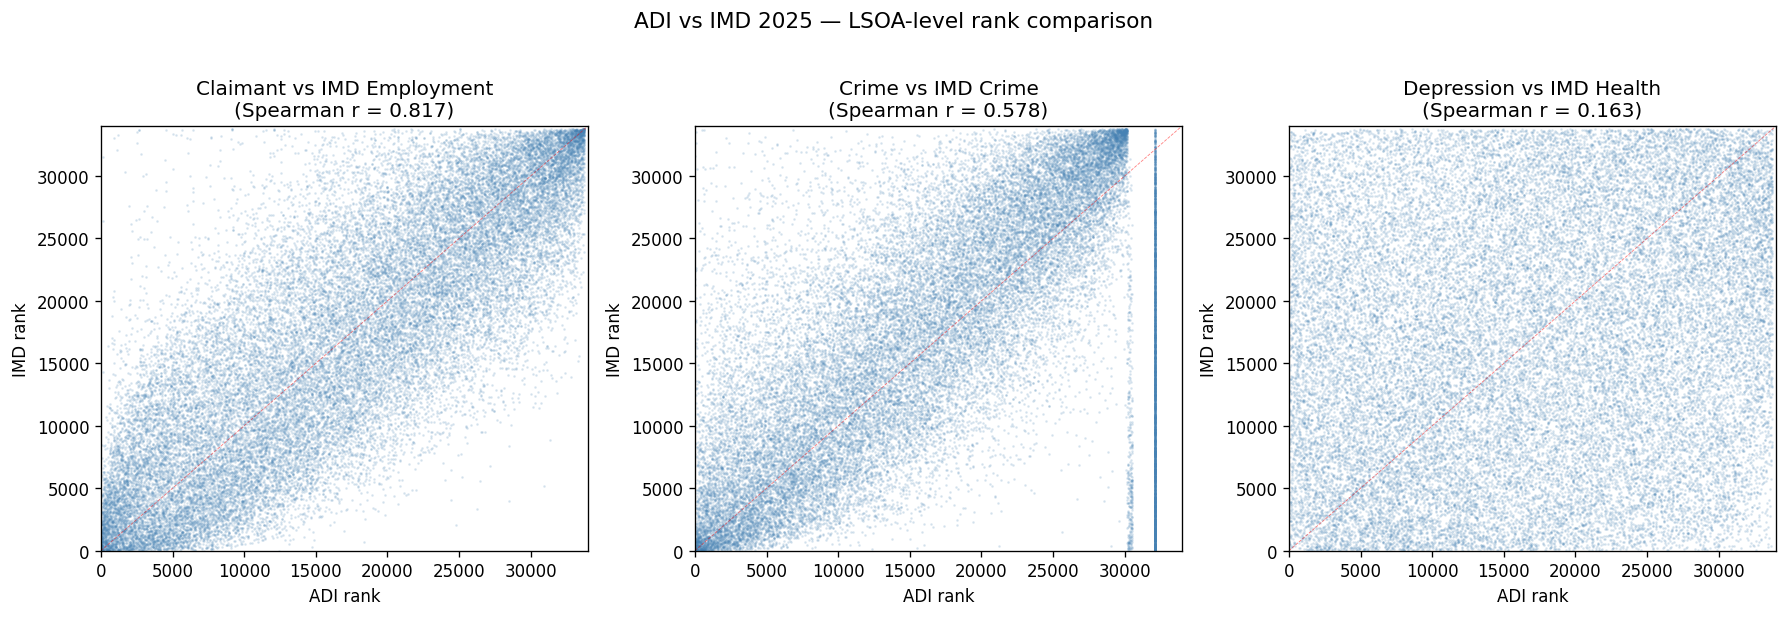

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (adi_col, imd_col, title) in zip(axes, [
    ("adi_claimant_rank", "imd_employment_rank", "Claimant vs IMD Employment"),
    ("adi_crime_rank", "imd_crime_rank", "Crime vs IMD Crime"),
    ("adi_dep_rank", "imd_health_rank", "Depression vs IMD Health"),
]):
    if adi_col not in m25.columns:
        ax.set_visible(False)
        continue
    r = correlate(m25[adi_col], m25[imd_col])
    ax.scatter(m25[adi_col], m25[imd_col], s=0.3, alpha=0.2, color="steelblue")
    ax.set_xlabel("ADI rank")
    ax.set_ylabel("IMD rank")
    ax.set_title(f"{title}\n(Spearman r = {r:.3f})")
    ax.plot([0, 34000], [0, 34000], "r--", linewidth=0.5, alpha=0.5)
    ax.set_xlim(0, 34000)
    ax.set_ylim(0, 34000)

fig.suptitle("ADI vs IMD 2025 — LSOA-level rank comparison", fontsize=13, y=1.02)
fig.tight_layout()
plt.savefig(repo_root / "store" / "outputs" / "adi_vs_imd_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## Correlation stability across IMD editions

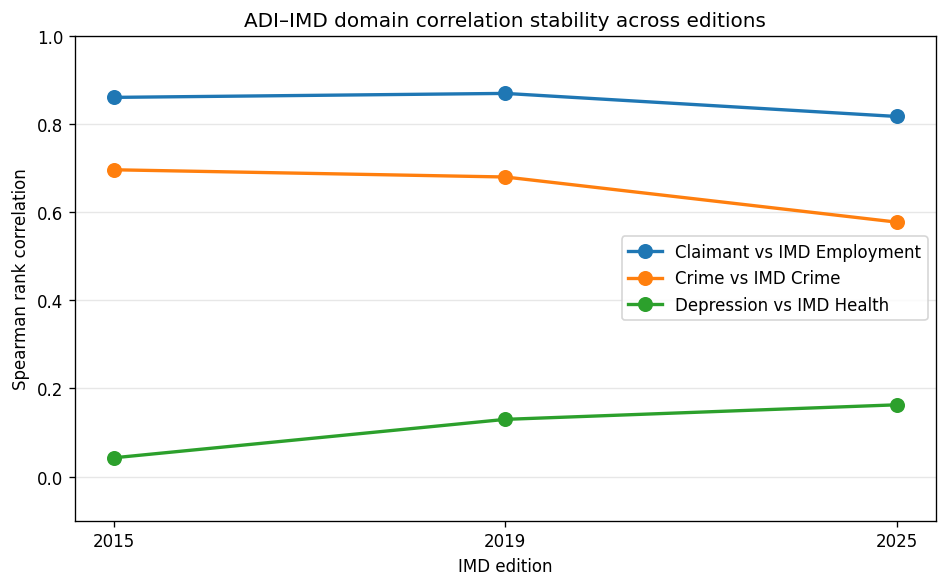

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
editions = ["2015", "2019", "2025"]
comparisons = [
    ("Claimant vs IMD Employment", "tab:blue"),
    ("Crime vs IMD Crime", "tab:orange"),
    ("Depression vs IMD Health", "tab:green"),
]
for comp_label, color in comparisons:
    if comp_label in results_df.columns:
        vals = results_df[comp_label].values
        ax.plot(editions, vals, "o-", label=comp_label, color=color, linewidth=2, markersize=8)

ax.set_ylabel("Spearman rank correlation")
ax.set_xlabel("IMD edition")
ax.set_title("ADI–IMD domain correlation stability across editions")
ax.legend(loc="center right")
ax.set_ylim(-0.1, 1.0)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.savefig(repo_root / "store" / "outputs" / "adi_imd_correlation_stability.png", dpi=150, bbox_inches="tight")
plt.show()

## Interpretation

**Employment domain (r = 0.82–0.87):** The ADI's claimant count rate is a
strong proxy for the IMD's Employment Deprivation domain. Both capture
worklessness, though through different measures (Universal Credit claimants
vs ILO unemployment + incapacity benefits). The slight decline from 0.87
(2019) to 0.82 (2025) may reflect the shift from legacy benefits to
Universal Credit changing the relationship.

**Crime domain (r = 0.58–0.70):** Moderate correlation that has been
declining over time. The IMD Crime domain uses a modelled rate accounting
for four crime types (burglary, theft, criminal damage, violence), while
the ADI uses raw police-recorded counts across 14 types. Differences in
recording practices and modelling explain the gap.

**Health domain (r ≈ 0):** QOF depression prevalence has essentially no
rank correlation with the IMD Health domain. This is expected — the IMD
Health domain measures premature mortality, acute hospital admissions,
comparative illness/disability ratios, and mood disorder prevalence. QOF
depression diagnosis captures a fundamentally different aspect of health
deprivation. The two are complementary, not redundant: the IMD captures
severe health outcomes, while the ADI captures chronic disease burden
at the primary care level.